# MultiWOZ result plots from saved analysis files

This notebook recreates the paper figures directly from the CSV files
produced by the dialogue-level and turn-level analysis notebooks.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Change this if your results folder is elsewhere.
RES_DIR = Path("../results")

# Expected result files from the analysis notebooks.
DIALOGUE_SPEARMAN_PATH = RES_DIR / "spearman_results.csv"
TURN_SPEARMAN_PATH = RES_DIR / "turn_spearman_results.csv"
TURN_GROUP_TESTS_PATH = RES_DIR / "turn_low_vs_high_tests.csv"

for path in [DIALOGUE_SPEARMAN_PATH, TURN_SPEARMAN_PATH, TURN_GROUP_TESTS_PATH]:
    print(path, "exists:" , path.exists())


..\results\spearman_results.csv exists: True
..\results\turn_spearman_results.csv exists: True
..\results\turn_low_vs_high_tests.csv exists: True


In [3]:
dialogue_corr = pd.read_csv(DIALOGUE_SPEARMAN_PATH)
turn_corr = pd.read_csv(TURN_SPEARMAN_PATH)
turn_groups = pd.read_csv(TURN_GROUP_TESTS_PATH)

display(dialogue_corr)
display(turn_corr)
display(turn_groups.head())


,mode,n,rho_jaccard_grice,p_jaccard_grice,rho_bleu_grice,p_bleu_grice
0,strict,10438,-0.097514,1.768257e-23,-0.009758,0.318851
1,normalized,10438,-0.079174,5.463722e-16,-0.022918,0.019209
2,lenient,10438,-0.065183,2.632630e-11,-0.013395,0.171166


,mode,n,rho_jaccard_grice,p_jaccard_grice,rho_bleu1_grice,p_bleu1_grice,rho_bleu4_grice,p_bleu4_grice
0,strict,142854,-0.097680,8.777797e-300,0.167393,0.0,0.051947,6.111280e-86
1,normalized,142854,-0.050892,1.482293e-82,0.142603,0.0,-0.016047,1.314221e-09
2,lenient,142854,-0.050418,4.673171e-81,0.142274,0.0,-0.014852,1.978891e-08


,mode,metric,q25,q75,n_low,n_high,low_mean_grice,high_mean_grice,difference_high_minus_low,mannwhitney_u,p_value
0,strict,jaccard,0.142857,0.400000,37433,35942,5.090356,4.999424,-0.090932,735508060.0,2.443211e-119
1,strict,bleu1_turn,8.208500,58.410059,35766,35829,4.832909,5.134308,0.301400,497980275.0,0.000000e+00
2,strict,bleu4_turn,4.978707,29.847459,40381,36419,4.890686,5.107632,0.216946,618353681.0,0.000000e+00
3,normalized,jaccard,0.166667,0.428571,38547,36709,5.092338,5.014155,-0.078183,768893057.0,9.954526e-107
4,normalized,bleu1_turn,13.533528,65.143906,37345,35862,4.850830,5.138834,0.288003,529233143.0,0.000000e+00


## Helper function for grouped bar charts


In [4]:
def grouped_bar(filename: str, title: str, ylabel: str, modes, labels_and_values, ylim=None):
    """Create and save a grouped bar chart.

    Args:
        filename: Output filename.
        title: Figure title.
        ylabel: Y-axis label.
        modes: Ordered list of matching regimes.
        labels_and_values: List of tuples (label, values).
        ylim: Optional y-axis limits.

    Returns:
        str: Saved path.
    """
    x = np.arange(len(modes))
    n = len(labels_and_values)
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=(9, 5.5))

    for i, (label, values) in enumerate(labels_and_values):
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=label)

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(modes)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    if ylim is not None:
        ax.set_ylim(*ylim)

    fig.tight_layout()
    out_path = RES_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_path.resolve())
    return str(out_path)


## 1. Dialogue-level correlations


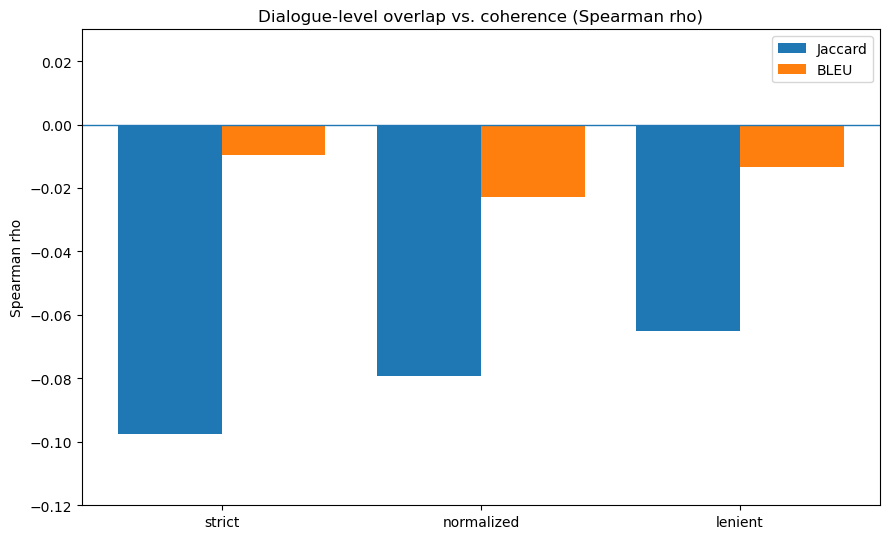

Saved: C:\Users\benwe\Documents\GitHub\multiwoz-grice-agreement\results\figure_dialogue_level_correlations.png


'..\\results\\figure_dialogue_level_correlations.png'

In [5]:
modes = ["strict", "normalized", "lenient"]
dialogue_corr = dialogue_corr.set_index("mode").loc[modes].reset_index()

grouped_bar(
    filename="figure_dialogue_level_correlations.png",
    title="Dialogue-level overlap vs. coherence (Spearman rho)",
    ylabel="Spearman rho",
    modes=modes,
    labels_and_values=[
        ("Jaccard", dialogue_corr["rho_jaccard_grice"].tolist()),
        ("BLEU", dialogue_corr["rho_bleu_grice"].tolist()),
    ],
    ylim=(-0.12, 0.03),
)


## 2. Turn-level correlations


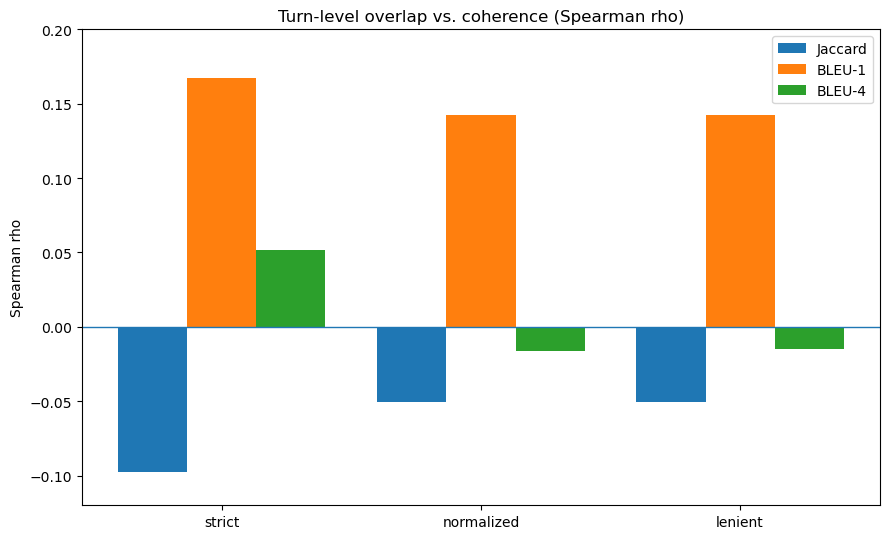

Saved: C:\Users\benwe\Documents\GitHub\multiwoz-grice-agreement\results\figure_turn_level_correlations.png


'..\\results\\figure_turn_level_correlations.png'

In [6]:
turn_corr = turn_corr.set_index("mode").loc[modes].reset_index()

grouped_bar(
    filename="figure_turn_level_correlations.png",
    title="Turn-level overlap vs. coherence (Spearman rho)",
    ylabel="Spearman rho",
    modes=modes,
    labels_and_values=[
        ("Jaccard", turn_corr["rho_jaccard_grice"].tolist()),
        ("BLEU-1", turn_corr["rho_bleu1_grice"].tolist()),
        ("BLEU-4", turn_corr["rho_bleu4_grice"].tolist()),
    ],
    ylim=(-0.12, 0.20),
)


## 3. Turn-level high-vs-low overlap differences


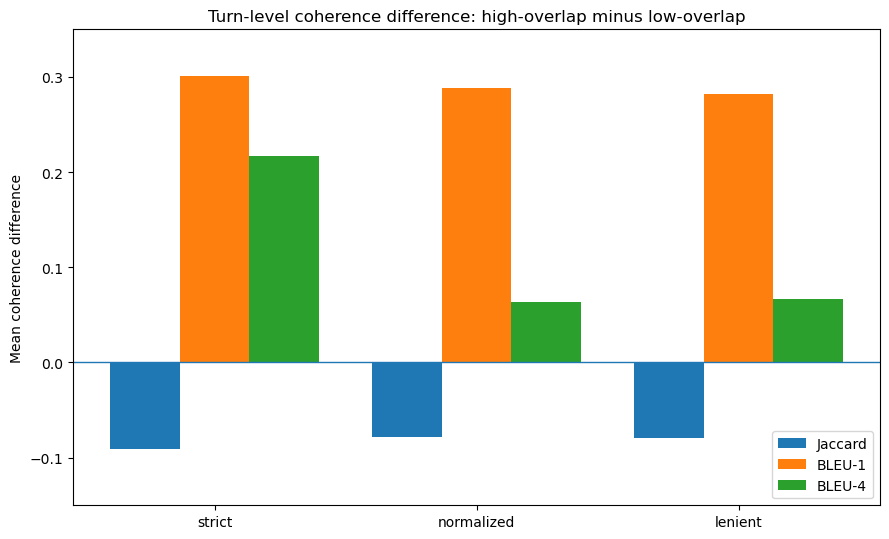

Saved: C:\Users\benwe\Documents\GitHub\multiwoz-grice-agreement\results\figure_turn_level_group_differences.png


'..\\results\\figure_turn_level_group_differences.png'

In [7]:
metric_map = {
    "jaccard": "Jaccard",
    "bleu1_turn": "BLEU-1",
    "bleu4_turn": "BLEU-4",
}

group_df = turn_groups.copy()
group_df = group_df[group_df["metric"].isin(metric_map.keys())]
group_df["metric_label"] = group_df["metric"].map(metric_map)

pivot = (
    group_df.pivot(index="mode", columns="metric_label", values="difference_high_minus_low")
    .loc[modes]
)

grouped_bar(
    filename="figure_turn_level_group_differences.png",
    title="Turn-level coherence difference: high-overlap minus low-overlap",
    ylabel="Mean coherence difference",
    modes=modes,
    labels_and_values=[
        ("Jaccard", pivot["Jaccard"].tolist()),
        ("BLEU-1", pivot["BLEU-1"].tolist()),
        ("BLEU-4", pivot["BLEU-4"].tolist()),
    ],
    ylim=(-0.15, 0.35),
)
